# Analysis of Fairness Throughput Data

This notebook analyzes the CSV output from `extract_fairness_throughput.py`, focusing on BBRv3 improvement metrics and fairness indicators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Color palette
C_V2    = "#d1495b"
C_V3    = "#2e86ab"
C_CUBIC = "#73726c"
C_POS   = "#2a8c5e"
C_NEG   = "#bf4040"

## Load Data

Load the CSV file generated by `extract_fairness_throughput.py`.

In [2]:
# Configuration
csv_file = Path("../out/fairness_throughput.csv")  # Adjust path as needed

# Load the CSV file
if csv_file.exists():
    df = pd.read_csv(csv_file)
    print(f"✓ Loaded {len(df)} rows from {csv_file}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    print(df.head())
else:
    print(f"Error: File not found at {csv_file}")

✓ Loaded 18 rows from ../out/fairness_throughput.csv

Columns: ['rtt', 'bw', 'loss', 'buf', 'bbrv2', 'bbrv3', 'cubic', 'cubicvsbbrv2', 'cubicvsbbrv3', 'cubicvscubic', 'v3ImprovPcnt', 'v2Harm', 'v3Harm', 'cubicHarm']

First few rows:
   rtt   bw  loss     buf      bbrv2      bbrv3      cubic  cubicvsbbrv2  \
0   10  100     0  0.1bdp  13.990276  14.070977  11.100265      4.830068   
1   10  100     0   10bdp  94.281072  93.607721  95.627709     85.092473   
2   10  100     0    1bdp  91.284608  94.100002  94.952563     66.653816   
3   10  100     2  0.1bdp   9.499448  10.887154   5.808728      4.215002   
4   10  100     2   10bdp  10.446534  16.971652   5.941440      6.843221   

   cubicvsbbrv3  cubicvscubic  v3ImprovPcnt    v2Harm    v3Harm  cubicHarm  
0      3.900447      5.221569      0.576840  0.564869  0.648617   0.529600  
1     47.407177     41.929257     -0.714196  0.110169  0.504253   0.561537  
2     35.965077     48.091233      3.084193  0.298030  0.621231   0.493524  
3 

## Data Exploration

Examine the structure and unique values in the dataset.

In [3]:
# Helper functions
def bar_positions(n_groups, n_bars, width=0.22):
    """Return x positions and bar-centre offsets for a grouped bar chart."""
    x = np.arange(n_groups)
    offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * width
    return x, offsets


def style_ax(ax, ylabel="", zero_line=False):
    """Apply consistent styling to axes."""
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linewidth=0.4, alpha=0.5)
    if zero_line:
        ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)


def set_hierarchical_labels(ax, n_rtt, n_bdp, rtt_labels, bdp_labels):
    """Set hierarchical x-axis labels for grouped 3-bar configurations.
    
    Args:
        ax: matplotlib axis
        n_rtt: number of RTT values
        n_bdp: number of BDP values (3)
        rtt_labels: list of RTT labels
        bdp_labels: list of BDP labels
    """
    # One x-position per 3-bar group (a single RTT/BDP combination)
    n_groups = n_rtt * n_bdp
    bdp_ticks = list(range(n_groups))
    bdp_labels_full = bdp_labels * n_rtt

    # Bottom axis: BDP labels for each 3-bar group
    ax.set_xticks(bdp_ticks)
    ax.set_xticklabels(bdp_labels_full, fontsize=8)
    ax.tick_params(axis="x", which="major", pad=3, length=0)

    # Top axis: RTT labels centered over each 3-group block
    top_ax = ax.secondary_xaxis("top")
    rtt_ticks = [i * n_bdp + (n_bdp - 1) / 2 for i in range(n_rtt)]
    top_ax.set_xticks(rtt_ticks)
    top_ax.set_xticklabels(rtt_labels, fontsize=9, fontweight="bold")
    top_ax.tick_params(axis="x", which="major", pad=6, length=0)
    top_ax.spines["top"].set_visible(False)

    # Add vertical lines to separate RTT groups
    for i in range(1, n_rtt):
        ax.axvline(i * n_bdp - 0.5, color="gray", linewidth=1.5, alpha=0.5, linestyle="-")


patch_csv_file = Path("../out/fairness_throughput_patch.csv")


def recompute_bbrv3_dependent_metrics(frame):
    result = frame.copy()
    bbrv2 = pd.to_numeric(result["bbrv2"], errors="coerce") if "bbrv2" in result.columns else pd.Series(np.nan, index=result.index)
    bbrv3 = pd.to_numeric(result["bbrv3"], errors="coerce") if "bbrv3" in result.columns else pd.Series(np.nan, index=result.index)
    cubic = pd.to_numeric(result["cubic"], errors="coerce") if "cubic" in result.columns else pd.Series(np.nan, index=result.index)
    cubic_vs_bbrv3 = pd.to_numeric(result["cubicvsbbrv3"], errors="coerce") if "cubicvsbbrv3" in result.columns else pd.Series(np.nan, index=result.index)

    valid_v3 = bbrv2.notna() & bbrv3.notna() & (bbrv2 != 0)
    result["v3ImprovPcnt"] = np.where(valid_v3, ((bbrv3 - bbrv2) / bbrv2) * 100, np.nan)

    valid_harm = cubic.notna() & cubic_vs_bbrv3.notna() & (cubic != 0)
    result["v3Harm"] = np.where(valid_harm, (cubic - cubic_vs_bbrv3) / cubic, np.nan)
    return result


df = recompute_bbrv3_dependent_metrics(df)
df_patch = df.copy()

if patch_csv_file.exists():
    df_patch_raw = pd.read_csv(patch_csv_file)
    patch_cols = [col for col in ["bbrv3", "cubicvsbbrv3"] if col in df_patch_raw.columns]
    if patch_cols:
        df_patch = df.merge(df_patch_raw[["rtt", "bw", "loss", "buf"] + patch_cols], on=["rtt", "bw", "loss", "buf"], how="left", suffixes=("", "_patch"))
        if "bbrv3_patch" in df_patch.columns:
            df_patch["bbrv3"] = df_patch["bbrv3_patch"].combine_first(df_patch["bbrv3"])
        if "cubicvsbbrv3_patch" in df_patch.columns:
            df_patch["cubicvsbbrv3"] = df_patch["cubicvsbbrv3_patch"].combine_first(df_patch["cubicvsbbrv3"])
        drop_cols = [col for col in ["bbrv3_patch", "cubicvsbbrv3_patch"] if col in df_patch.columns]
        if drop_cols:
            df_patch = df_patch.drop(columns=drop_cols)
        df_patch = recompute_bbrv3_dependent_metrics(df_patch)
    print(f"✓ Loaded {len(df_patch_raw)} rows from {patch_csv_file}")
else:
    print(f"⚠ Patch file not found at {patch_csv_file}; using base data for both views")

print("Unique RTT values:", sorted(df["rtt"].unique()))
print("Unique BW values:", sorted(df["bw"].unique()))
print("Unique Loss values:", sorted(df["loss"].unique()))
print("Unique Buffer values:", sorted(df["buf"].unique()))

# Create a categorical column for loss (with/without)
df["loss_cat"] = df["loss"].apply(lambda x: "Loss" if x > 0 else "0% Loss")

# Convert buffer column to numeric where possible, keep string for mixed formats
def parse_buffer(buf_str):
    """Parse buffer string, returning numeric value."""
    if pd.isna(buf_str):
        return None
    try:
        return float(str(buf_str).replace("bdp", ""))
    except:
        return str(buf_str)

df["buf_numeric"] = df["buf"].apply(parse_buffer)

# Create labels for x-axis (e.g., "rtt10 0.1bdp L0")
df["label"] = df.apply(lambda r: f"rtt{r.rtt} {r.buf} L{r.loss}", axis=1)
df_patch["loss_cat"] = df_patch["loss"].apply(lambda x: "Loss" if x > 0 else "0% Loss")
df_patch["buf_numeric"] = df_patch["buf"].apply(parse_buffer)
df_patch["label"] = df_patch.apply(lambda r: f"rtt{r.rtt} {r.buf} L{r.loss}", axis=1)

plot_sources = [("Unpatched", df), ("Patched", df_patch)]

print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

✓ Loaded 18 rows from ../out/fairness_throughput_patch.csv
Unique RTT values: [np.int64(10), np.int64(50), np.int64(100)]
Unique BW values: [np.int64(100)]
Unique Loss values: [np.int64(0), np.int64(2)]
Unique Buffer values: ['0.1bdp', '10bdp', '1bdp']

DataFrame shape: (18, 17)
Columns: ['rtt', 'bw', 'loss', 'buf', 'bbrv2', 'bbrv3', 'cubic', 'cubicvsbbrv2', 'cubicvsbbrv3', 'cubicvscubic', 'v3ImprovPcnt', 'v2Harm', 'v3Harm', 'cubicHarm', 'loss_cat', 'buf_numeric', 'label']


In [4]:
graphs_dir = Path("../graphs")
graphs_dir.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    output_path = graphs_dir / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"✓ Saved figure to {output_path}")

In [5]:
patched_csv_file = Path("../out/fairness_throughput_patched.csv")
df_patch.to_csv(patched_csv_file, index=False)
print(f"✓ Wrote patched dataframe to {patched_csv_file}")

✓ Wrote patched dataframe to ../out/fairness_throughput_patched.csv


## v3 Improvement Analysis

Analyze BBRv3 improvement over BBRv2 (`v3ImprovPcnt`) across different network configurations.

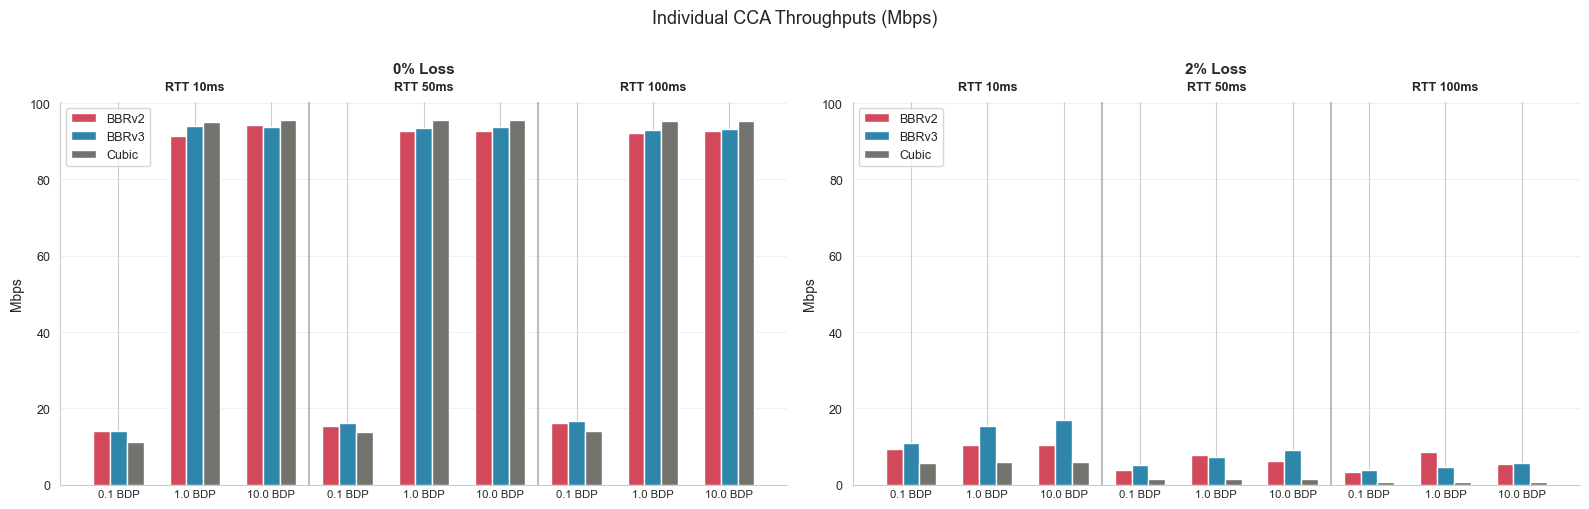

✓ Saved figure to ../graphs/solo_throughputs_unpatched.png
Plot 1 complete (Unpatched): 18 configurations


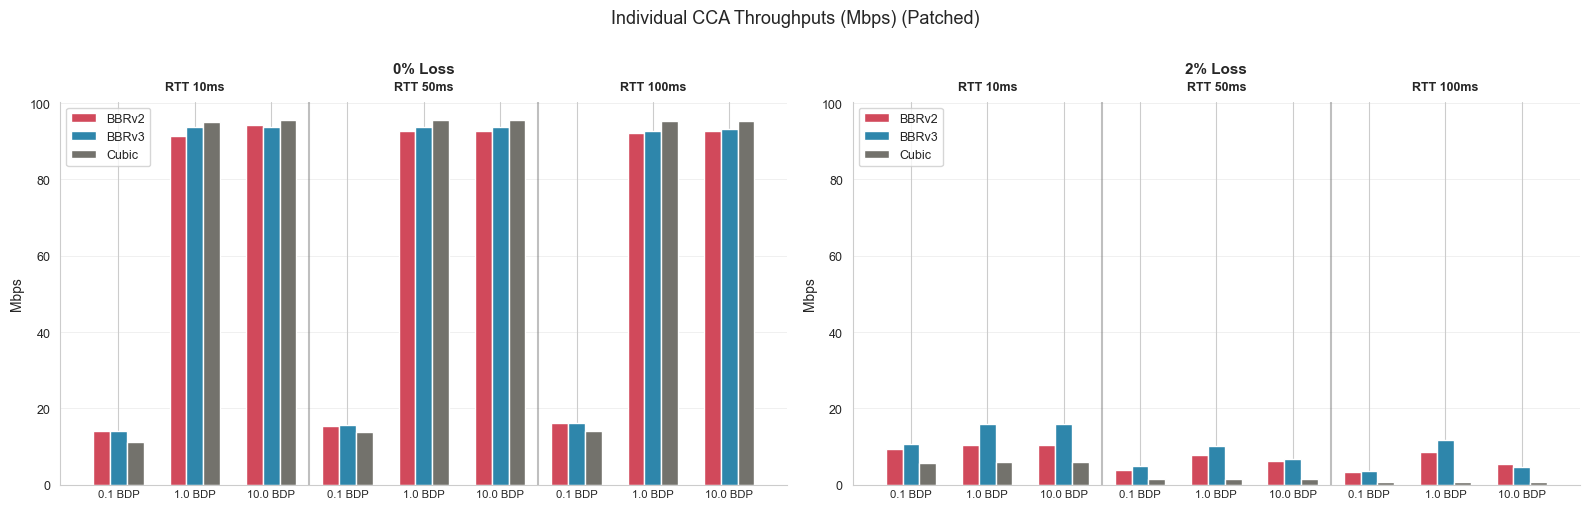

✓ Saved figure to ../graphs/solo_throughputs_patched.png
Plot 1 complete (Patched): 18 configurations


In [9]:
## Plot 1: Solo Throughput Comparison

# Clean data
# Plot both the original and patched BBRv3 values
bdp_order = ["0.1bdp", "1bdp", "10bdp"]
bdp_labels = ["0.1 BDP", "1.0 BDP", "10.0 BDP"]


# Helper to compute a global y-limit across multiple dataframes for the solo throughput bars
def compute_global_ylim_for_solo(df_list, cols, loss_vals=[0, 2], pad=0.05, mode='nonnegative', robust_pct=95):
    """Compute a shared y-axis range.

    mode:
      - 'nonnegative' (default): floor ymin at 0 (good for throughput)
      - 'symmetric' : symmetric about zero using max absolute value
      - 'symmetric_robust': symmetric about zero using the `robust_pct` percentile of absolute values (reduces outlier influence)
    """
    all_vals = []
    for d in df_list:
        if d is None or d.empty:
            continue
        for loss in loss_vals:
            sel = d[d["loss"] == loss] if "loss" in d.columns else d
            if sel.empty:
                continue
            for c in cols:
                if c in sel.columns:
                    all_vals.extend(pd.to_numeric(sel[c], errors="coerce").dropna().tolist())
    if not all_vals:
        return 0, 1
    arr = np.array(all_vals)
    ymin = float(np.nanmin(arr))
    ymax = float(np.nanmax(arr))

    if mode == 'symmetric_robust':
        abs_vals = np.abs(arr)
        q = np.nanpercentile(abs_vals, robust_pct)
        max_abs = float(q)
        if max_abs == 0:
            return -0.05, 0.05
        ymin = -max_abs * (1 + pad)
        ymax =  max_abs * (1 + pad)
        return ymin, ymax

    if mode == 'symmetric':
        max_abs = max(abs(ymin), abs(ymax))
        if max_abs == 0:
            return -0.05, 0.05
        ymin = -max_abs * (1 + pad)
        ymax =  max_abs * (1 + pad)
        return ymin, ymax

    # nonnegative/default behavior
    rng = ymax - ymin
    if rng == 0:
        ymin = ymin - 0.05 * abs(ymin) if ymin != 0 else -0.05
        ymax = ymax + 0.05 * abs(ymax) if ymax != 0 else 0.05
    else:
        ymin = ymin - pad * rng
        ymax = ymax + pad * rng
    ymin = max(0, ymin)
    return ymin, ymax

# Pre-compute a shared y-range for solo throughputs across both unpatched and patched datasets
solo_cols = ["bbrv2", "bbrv3", "cubic"]
shared_ymin, shared_ymax = compute_global_ylim_for_solo([df, df_patch], solo_cols)

for scenario_name, df_source in plot_sources:
    fig1, (ax1_left, ax1_right) = plt.subplots(1, 2, figsize=(16, 5))
    fig1_title = "Individual CCA Throughputs (Mbps)"
    if scenario_name == "Patched":
        fig1_title += " (Patched)"
    fig1.suptitle(fig1_title, fontsize=13, fontweight="medium", y=1.01)

    df_plot = df_source[df_source["bbrv2"].notna() & df_source["bbrv3"].notna() & df_source["cubic"].notna()].copy()
    rtt_order = sorted(df_source["rtt"].unique())
    rtt_labels = [f"RTT {int(r)}ms" for r in rtt_order]

    for ax, loss_val, loss_name in [(ax1_left, 0, "0% Loss"), (ax1_right, 2, "2% Loss")]:
        df_loss = df_plot[df_plot["loss"] == loss_val].copy()
        
        if len(df_loss) > 0:
            # Sort by RTT, then by BDP order
            df_loss["buf_order"] = df_loss["buf"].apply(lambda x: bdp_order.index(x) if x in bdp_order else 999)
            df_loss = df_loss.sort_values(["rtt", "buf_order"])
            
            x = np.arange(len(df_loss))
            w = 0.22
            
            ax.bar(x - w, df_loss["bbrv2"],  w, color=C_V2,    label="BBRv2")
            ax.bar(x,     df_loss["bbrv3"],  w, color=C_V3,    label="BBRv3")
            ax.bar(x + w, df_loss["cubic"],  w, color=C_CUBIC, label="Cubic")
            
            # Set hierarchical labels
            set_hierarchical_labels(ax, len(rtt_order), len(bdp_order), rtt_labels, bdp_labels)
            
            # Apply shared y-limits for consistent comparison across loss & patch variants
            ax.set_ylim(shared_ymin, shared_ymax)

            ax.set_title(f"{loss_name}", fontsize=11, fontweight="bold")
            style_ax(ax, ylabel="Mbps")
            ax.legend(fontsize=9, loc="upper left")

    fig1.tight_layout()
    plt.show()
    save_figure(fig1, f"solo_throughputs_{scenario_name.lower().replace(' ', '_')}.png")

    print(f"Plot 1 complete ({scenario_name}): {len(df_plot)} configurations")

### Faceted View: All Network Configurations

This plot shows v3ImprovPcnt separated by RTT (rows), bandwidth (columns), and loss condition (color). Each cell represents a buffer size on the x-axis.

DEBUG Plot2 shared_ymin=-52.247107559291344, shared_ymax=52.247107559291344


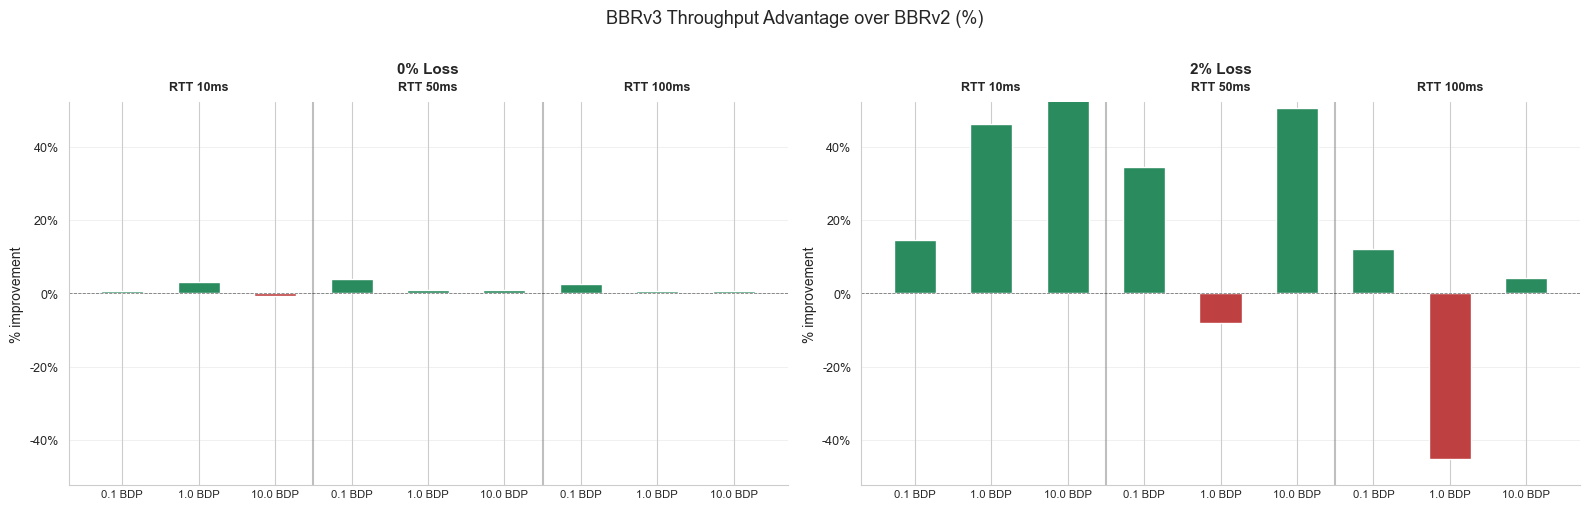

✓ Saved figure to ../graphs/bbrv3_advantage_unpatched.png
Plot 2 complete (Unpatched): 18 configurations
DEBUG Plot2 shared_ymin=-52.247107559291344, shared_ymax=52.247107559291344


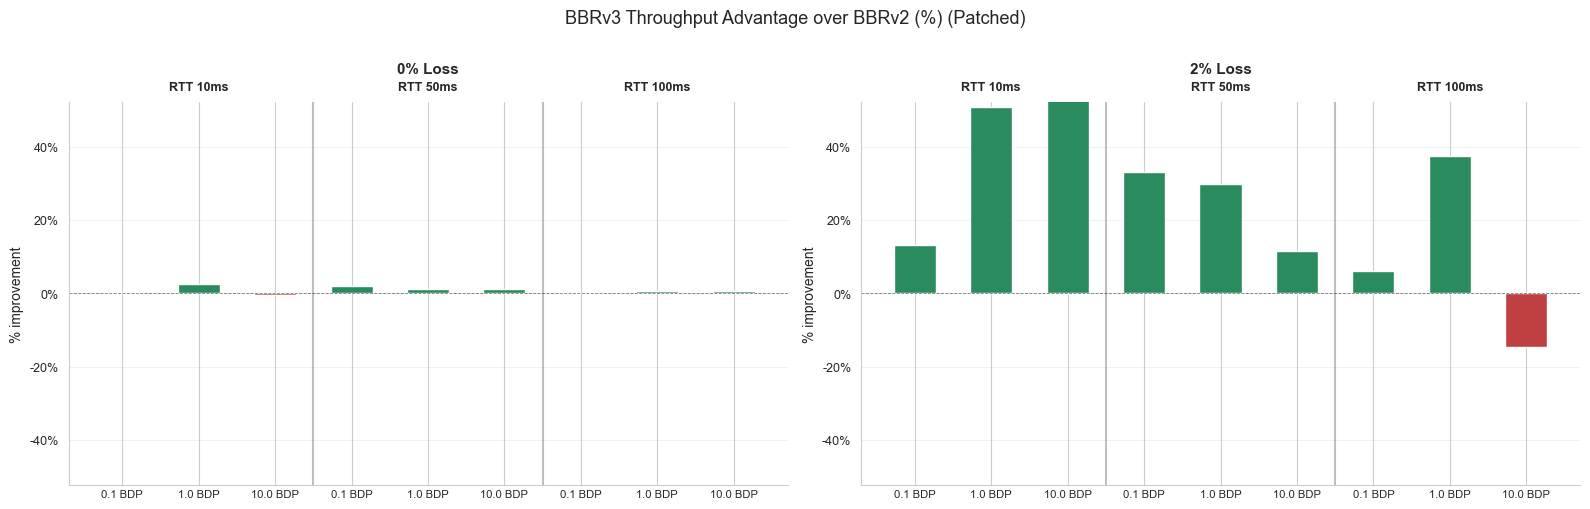

✓ Saved figure to ../graphs/bbrv3_advantage_patched.png
Plot 2 complete (Patched): 18 configurations


In [7]:
## Plot 2: BBRv3 Advantage over BBRv2

# Define BDP order and labels
bdp_order = ["0.1bdp", "1bdp", "10bdp"]
bdp_labels = ["0.1 BDP", "1.0 BDP", "10.0 BDP"]

for scenario_name, df_source in plot_sources:
    fig2, (ax2_left, ax2_right) = plt.subplots(1, 2, figsize=(16, 5))
    fig2_title = "BBRv3 Throughput Advantage over BBRv2 (%)"
    if scenario_name == "Patched":
        fig2_title += " (Patched)"
    fig2.suptitle(fig2_title, fontsize=13, fontweight="medium", y=1.01)

    df_plot2 = df_source[df_source["v3ImprovPcnt"].notna()].copy()
    df_plot2["v3ImprovPcnt"] = pd.to_numeric(df_plot2["v3ImprovPcnt"], errors="coerce")
    df_plot2 = df_plot2.dropna(subset=["v3ImprovPcnt"])
    rtt_order = sorted(df_source["rtt"].unique())
    rtt_labels = [f"RTT {int(r)}ms" for r in rtt_order]

    # Compute a shared y-range for this metric across patched/unpatched and loss panels (robust symmetric so negatives show and outliers don't dominate)
    try:
        shared_ymin, shared_ymax = compute_global_ylim_for_solo([df, df_patch], ["v3ImprovPcnt"], loss_vals=[0, 2], pad=0.08, mode='symmetric_robust', robust_pct=90)
        print(f"DEBUG Plot2 shared_ymin={shared_ymin}, shared_ymax={shared_ymax}")
    except Exception as e:
        shared_ymin, shared_ymax = None, None
        print(f"DEBUG Plot2 compute_global error: {e}")

    for ax, loss_val, loss_name in [(ax2_left, 0, "0% Loss"), (ax2_right, 2, "2% Loss")]:
        df_loss = df_plot2[df_plot2["loss"] == loss_val].copy()
        
        if len(df_loss) > 0:
            # Sort by RTT, then by BDP order
            df_loss["buf_order"] = df_loss["buf"].apply(lambda x: bdp_order.index(x) if x in bdp_order else 999)
            df_loss = df_loss.sort_values(["rtt", "buf_order"])
            
            x = np.arange(len(df_loss))
            
            # Color bars based on positive/negative
            colors = [C_POS if v >= 0 else C_NEG for v in df_loss["v3ImprovPcnt"]]
            ax.bar(x, df_loss["v3ImprovPcnt"], width=0.55, color=colors)
            
            # Set hierarchical labels
            set_hierarchical_labels(ax, len(rtt_order), len(bdp_order), rtt_labels, bdp_labels)
            
            # Apply shared y-limits if computed
            if shared_ymin is not None and shared_ymax is not None:
                ax.set_ylim(shared_ymin, shared_ymax)

            ax.set_title(f"{loss_name}", fontsize=11, fontweight="bold")
            style_ax(ax, ylabel="% improvement", zero_line=True)
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

    fig2.tight_layout()
    plt.show()
    save_figure(fig2, f"bbrv3_advantage_{scenario_name.lower().replace(' ', '_')}.png")

    print(f"Plot 2 complete ({scenario_name}): {len(df_plot2)} configurations")

## Summary Statistics

Statistical breakdown of key metrics by loss condition, RTT, and buffer size.

DEBUG Plot3 shared_ymin=-0.6791147476208902, shared_ymax=0.6791147476208902


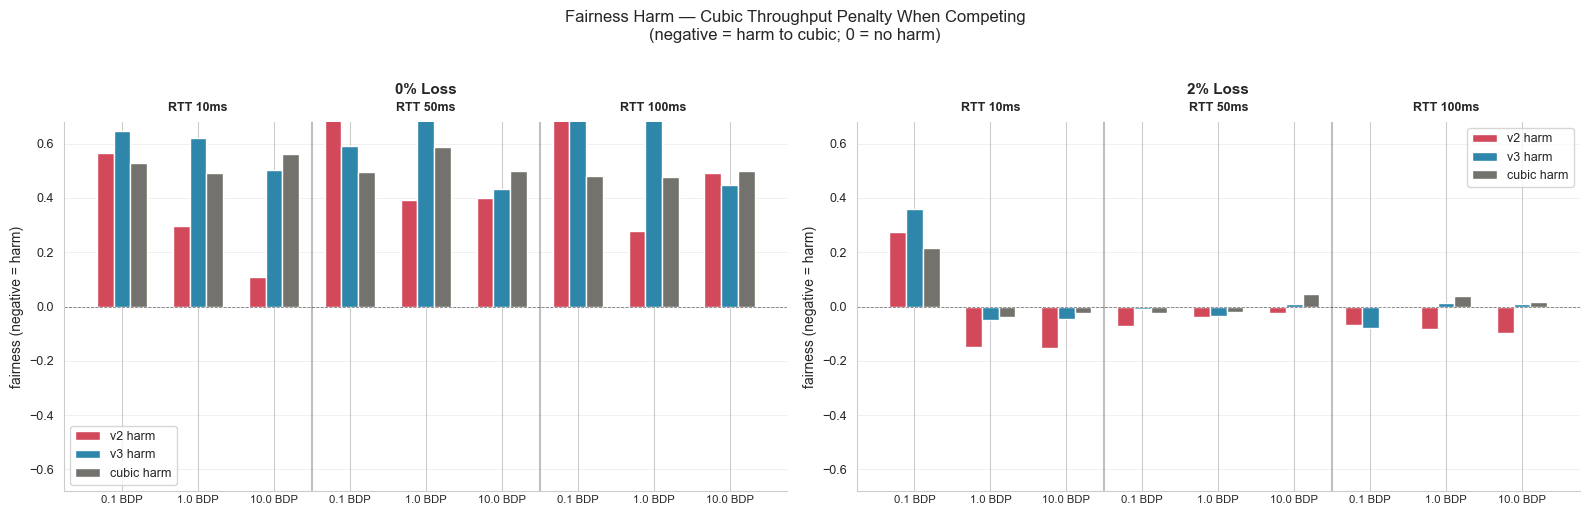

✓ Saved figure to ../graphs/fairness_harm_unpatched.png
Plot 3 complete (Unpatched): 18 configurations
DEBUG Plot3 shared_ymin=-0.6791147476208902, shared_ymax=0.6791147476208902


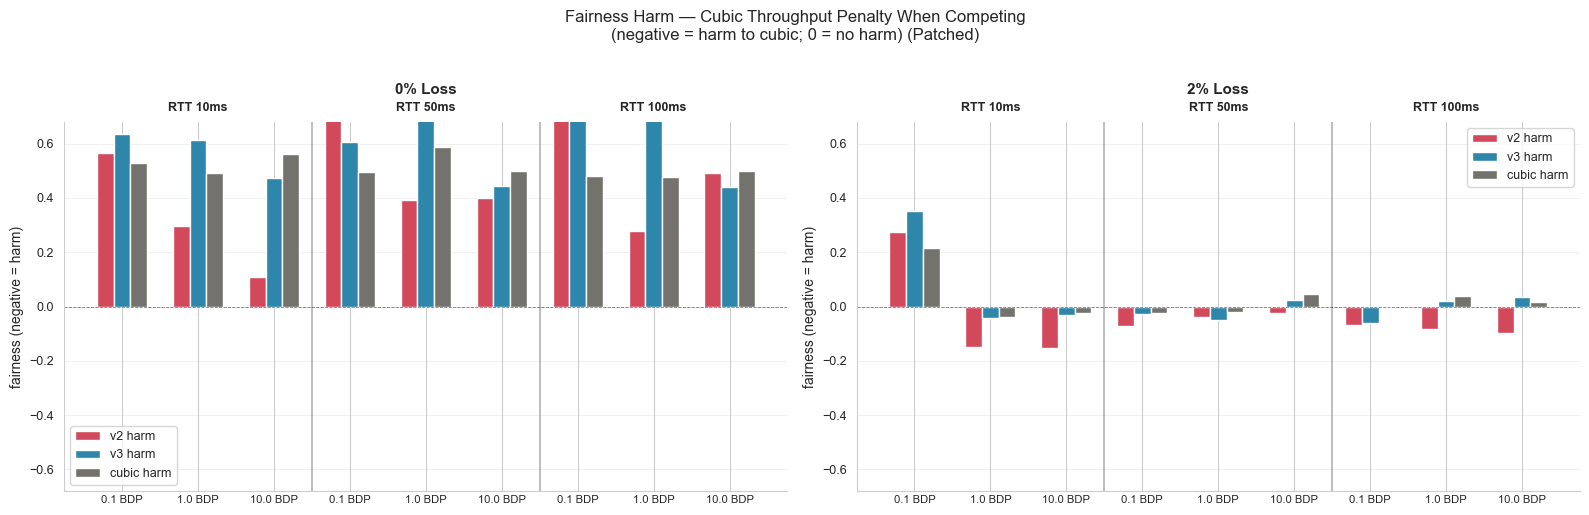

✓ Saved figure to ../graphs/fairness_harm_patched.png
Plot 3 complete (Patched): 18 configurations


In [8]:
## Plot 3: Fairness Harm Analysis

# Define BDP order and labels
bdp_order = ["0.1bdp", "1bdp", "10bdp"]
bdp_labels = ["0.1 BDP", "1.0 BDP", "10.0 BDP"]
harm_cols = ["v2Harm", "v3Harm", "cubicHarm"]
colors_map = {
    "v2Harm": C_V2,
    "v3Harm": C_V3,
    "cubicHarm": C_CUBIC,
}

for scenario_name, df_source in plot_sources:
    fig3, (ax3_left, ax3_right) = plt.subplots(1, 2, figsize=(16, 5))
    fig3_title = "Fairness Harm — Cubic Throughput Penalty When Competing\n(negative = harm to cubic; 0 = no harm)"
    if scenario_name == "Patched":
        fig3_title += " (Patched)"
    fig3.suptitle(fig3_title, fontsize=12, fontweight="medium", y=1.02)

    harm_present = [col for col in harm_cols if col in df_source.columns]
    df_plot3 = df_source[df_source[harm_present].notna().any(axis=1)].copy() if harm_present else pd.DataFrame()

    for col in harm_present:
        df_plot3[col] = pd.to_numeric(df_plot3[col], errors="coerce")

    rtt_order = sorted(df_source["rtt"].unique())
    rtt_labels = [f"RTT {int(r)}ms" for r in rtt_order]

    # Compute shared y-limits across both loss panels and patched/unpatched for harm metrics (robust symmetric so negatives show and outliers don't dominate)
    try:
        shared_ymin, shared_ymax = compute_global_ylim_for_solo([df, df_patch], harm_present, loss_vals=[0, 2], pad=0.06, mode='symmetric_robust', robust_pct=90)
        print(f"DEBUG Plot3 shared_ymin={shared_ymin}, shared_ymax={shared_ymax}")
    except Exception as e:
        shared_ymin, shared_ymax = None, None
        print(f"DEBUG Plot3 compute_global error: {e}")

    if len(df_plot3) > 0 and len(harm_present) > 0:
        cols_to_plot = harm_present
        n_bars = len(cols_to_plot)

        for ax, loss_val, loss_name in [(ax3_left, 0, "0% Loss"), (ax3_right, 2, "2% Loss")]:
            df_loss = df_plot3[df_plot3["loss"] == loss_val].copy()

            if len(df_loss) > 0:
                # Sort by RTT, then by BDP order
                df_loss["buf_order"] = df_loss["buf"].apply(lambda x: bdp_order.index(x) if x in bdp_order else 999)
                df_loss = df_loss.sort_values(["rtt", "buf_order"])

                x, offsets = bar_positions(len(df_loss), n_bars)
                w = 0.22

                for i, col in enumerate(cols_to_plot):
                    ax.bar(x + offsets[i], df_loss[col], w, color=colors_map.get(col, "#999999"), label=col.replace("Harm", " harm"))

                # Set hierarchical labels
                set_hierarchical_labels(ax, len(rtt_order), len(bdp_order), rtt_labels, bdp_labels)

                # Apply shared y-limits if available
                if shared_ymin is not None and shared_ymax is not None:
                    ax.set_ylim(shared_ymin, shared_ymax)

                ax.set_title(f"{loss_name}", fontsize=11, fontweight="bold")
                style_ax(ax, ylabel="fairness (negative = harm)", zero_line=True)
                ax.legend(fontsize=9, loc="best")
            else:
                ax.set_axis_off()
                ax.set_title(f"{loss_name} (no data)", fontsize=11, fontweight="bold")

        fig3.tight_layout()
        plt.show()
        save_figure(fig3, f"fairness_harm_{scenario_name.lower().replace(' ', '_')}.png")

        print(f"Plot 3 complete ({scenario_name}): {len(df_plot3)} configurations")
    else:
        print(f"Fairness harm columns not found in data for {scenario_name}")